# Week 1 — Dataset Sample Explorer

This notebook runs all 10 sample-probe programs across the 5 medical imaging datasets.
Each section documents the dataset, the tools used, and executes the corresponding test script.

| # | Dataset | Modality | Domain | Format | Test(s) |
|---|---------|----------|--------|--------|---------|
| 1 | IQ-OTH/NCCD | CT (Chest) | Radiology | JPEG | `test_iq_oth` |
| 2 | OASIS-1 | MRI (Brain, T1) | Radiology | Analyze 7.5 | `test_oasis1` |
| 3 | PKG HistologyHSI-GB | Hyperspectral microscopy | Pathology | ENVI BIL | `test_pkg_hsi` |
| 4 | Quilt1M (×4 subsets) | Optical microscopy (H&E) | Pathology | JPEG | `test_quilt1m_*` |
| 5 | Spinal (DICOM) | Spectral CT (Spine) | Radiology | DICOM | `test_spinal_dicom` |
| 5 | Spinal (NIfTI) | CT-derived segmentation | Radiology | NIfTI | `test_spinal_nifti` |

---

## Environment Setup

All dependencies are listed in `requirements.txt`. Key libraries:
- **TissueLab-SDK** (`SimpleImageWrapper`, `DicomImageWrapper`, `NiftiImageWrapper`)
- `nibabel` — Analyze 7.5 / NIfTI volume loading
- `spectral` — ENVI BIL hyperspectral cubes
- `pydicom` — DICOM tag parsing and pixel data
- `SimpleITK` — 3D DICOM series reconstruction
- `pandas` — metadata CSV/TSV parsing
- `matplotlib` — all visualizations
- `Pillow` — direct JPEG/PNG loading

In [1]:
import sys, os
from pathlib import Path

# Add week1 to path so test modules and _quilt1m_common can be imported
WEEK1_DIR = Path(".").resolve()
if str(WEEK1_DIR) not in sys.path:
    sys.path.insert(0, str(WEEK1_DIR))

print(f"Working directory : {WEEK1_DIR}")
print(f"Python            : {sys.version}")

# Verify key dependencies
deps = ["nibabel", "spectral", "pydicom", "SimpleITK", "pandas", "matplotlib", "PIL"]
for dep in deps:
    try:
        mod = __import__(dep if dep != "PIL" else "PIL.Image", fromlist=[""])
        ver = getattr(mod, "__version__", "?")
        print(f"  ✓ {dep:<12} {ver}")
    except ImportError:
        print(f"  ✗ {dep:<12} NOT INSTALLED")

try:
    from tissuelab_sdk.wrapper import SimpleImageWrapper, DicomImageWrapper, NiftiImageWrapper
    print("  ✓ TissueLab-SDK  (SimpleImageWrapper, DicomImageWrapper, NiftiImageWrapper)")
except ImportError:
    print("  ✗ TissueLab-SDK  NOT INSTALLED")

Working directory : /Volumes/ExternalOwc/AI_For_Healthcare/Final_Project/ai-in-healthcare-high-risk-project/week1
Python            : 3.11.14 (main, Oct 28 2025, 12:11:54) [Clang 20.1.4 ]
  ✓ nibabel      5.4.2
  ✓ spectral     0.24
  ✓ pydicom      3.0.2
  ✓ SimpleITK    2.5.3
  ✓ pandas       2.3.3
  ✓ matplotlib   3.10.8
  ✓ PIL          11.0.0
  ✓ TissueLab-SDK  (SimpleImageWrapper, DicomImageWrapper, NiftiImageWrapper)


---

## 1. IQ-OTH/NCCD — Lung Cancer CT Dataset

### Background
Collected at the Iraq-Oncology Teaching Hospital / National Center for Cancer Diseases (fall 2019).
Contains **1,097 JPEG CT chest slice images** across **110 patients** in 3 classes:
- **Benign** — 120 images, 15 patients
- **Malignant** — 561 images, 40 patients
- **Normal** — 416 images, 55 patients

### Imaging Modality
**CT (Computed Tomography)** of the chest. Original DICOM from a SOMATOM Siemens scanner;
exported as 2D JPEG slices (1 mm slice thickness, 120 kV, 350–1200 HU window).

### Tools Used
| Tool | Role |
|------|------|
| `SimpleImageWrapper` (SDK) | Load JPEG via unified WSI-like interface; expose dimensions, level count, region reads |
| `PIL.Image` | Direct JPEG load; format, mode, size, EXIF tags |
| `numpy` | Pixel statistics: min/max/mean/std/histogram, per-channel RGB analysis |
| `matplotlib` | 3-panel visualization (one per class) + intensity histograms |

### Sample
One representative slice from each of the three classes:
- `data/IQ-OTH_NCCD/Benign/Benign_case_1.jpg`
- `data/IQ-OTH_NCCD/Malignant/Malignant_case_1.jpg`
- `data/IQ-OTH_NCCD/Normal/Normal_case_1.jpg`

### Clinical Relevance
Demonstrates the visual difference between benign pulmonary nodules, malignant masses, and
healthy lung parenchyma — the core input for any lung cancer screening AI model.

In [2]:
import importlib, test_iq_oth
importlib.reload(test_iq_oth)
test_iq_oth.main()


  IQ-OTH/NCCD Lung Cancer Dataset — Sample Probe
  Modality : Chest CT (JPEG slices)
  Domain   : Radiology

  CLASS: Benign
  FILE : Benign_case_1.jpg
  PIL format  : JPEG
  PIL mode    : RGB
  Dimensions  : 512W × 512H
  SDK wrapper : SimpleImageWrapper
  SDK dims    : [512, 512]
  Level count : 1
  Shape       : [512, 512, 3]
  Dtype       : uint8
  Intensity   : min=37.0  max=255.0  mean=96.9  std=76.3
  Percentiles : p5=38.0  p95=232.0
  Channels    : R_mean=96.8933  G_mean=96.8933  B_mean=96.8933

  CLASS: Malignant
  FILE : Malignant_case_1.jpg
  PIL format  : JPEG
  PIL mode    : RGB
  Dimensions  : 512W × 512H
  SDK wrapper : SimpleImageWrapper
  SDK dims    : [512, 512]
  Level count : 1
  Shape       : [512, 512, 3]
  Dtype       : uint8
  Intensity   : min=37.0  max=255.0  mean=87.1  std=72.0
  Percentiles : p5=38.0  p95=231.0
  Channels    : R_mean=87.1196  G_mean=87.1196  B_mean=87.1196

  CLASS: Normal
  FILE : Normal_case_1.jpg
  PIL format  : JPEG
  PIL mode    : RGB


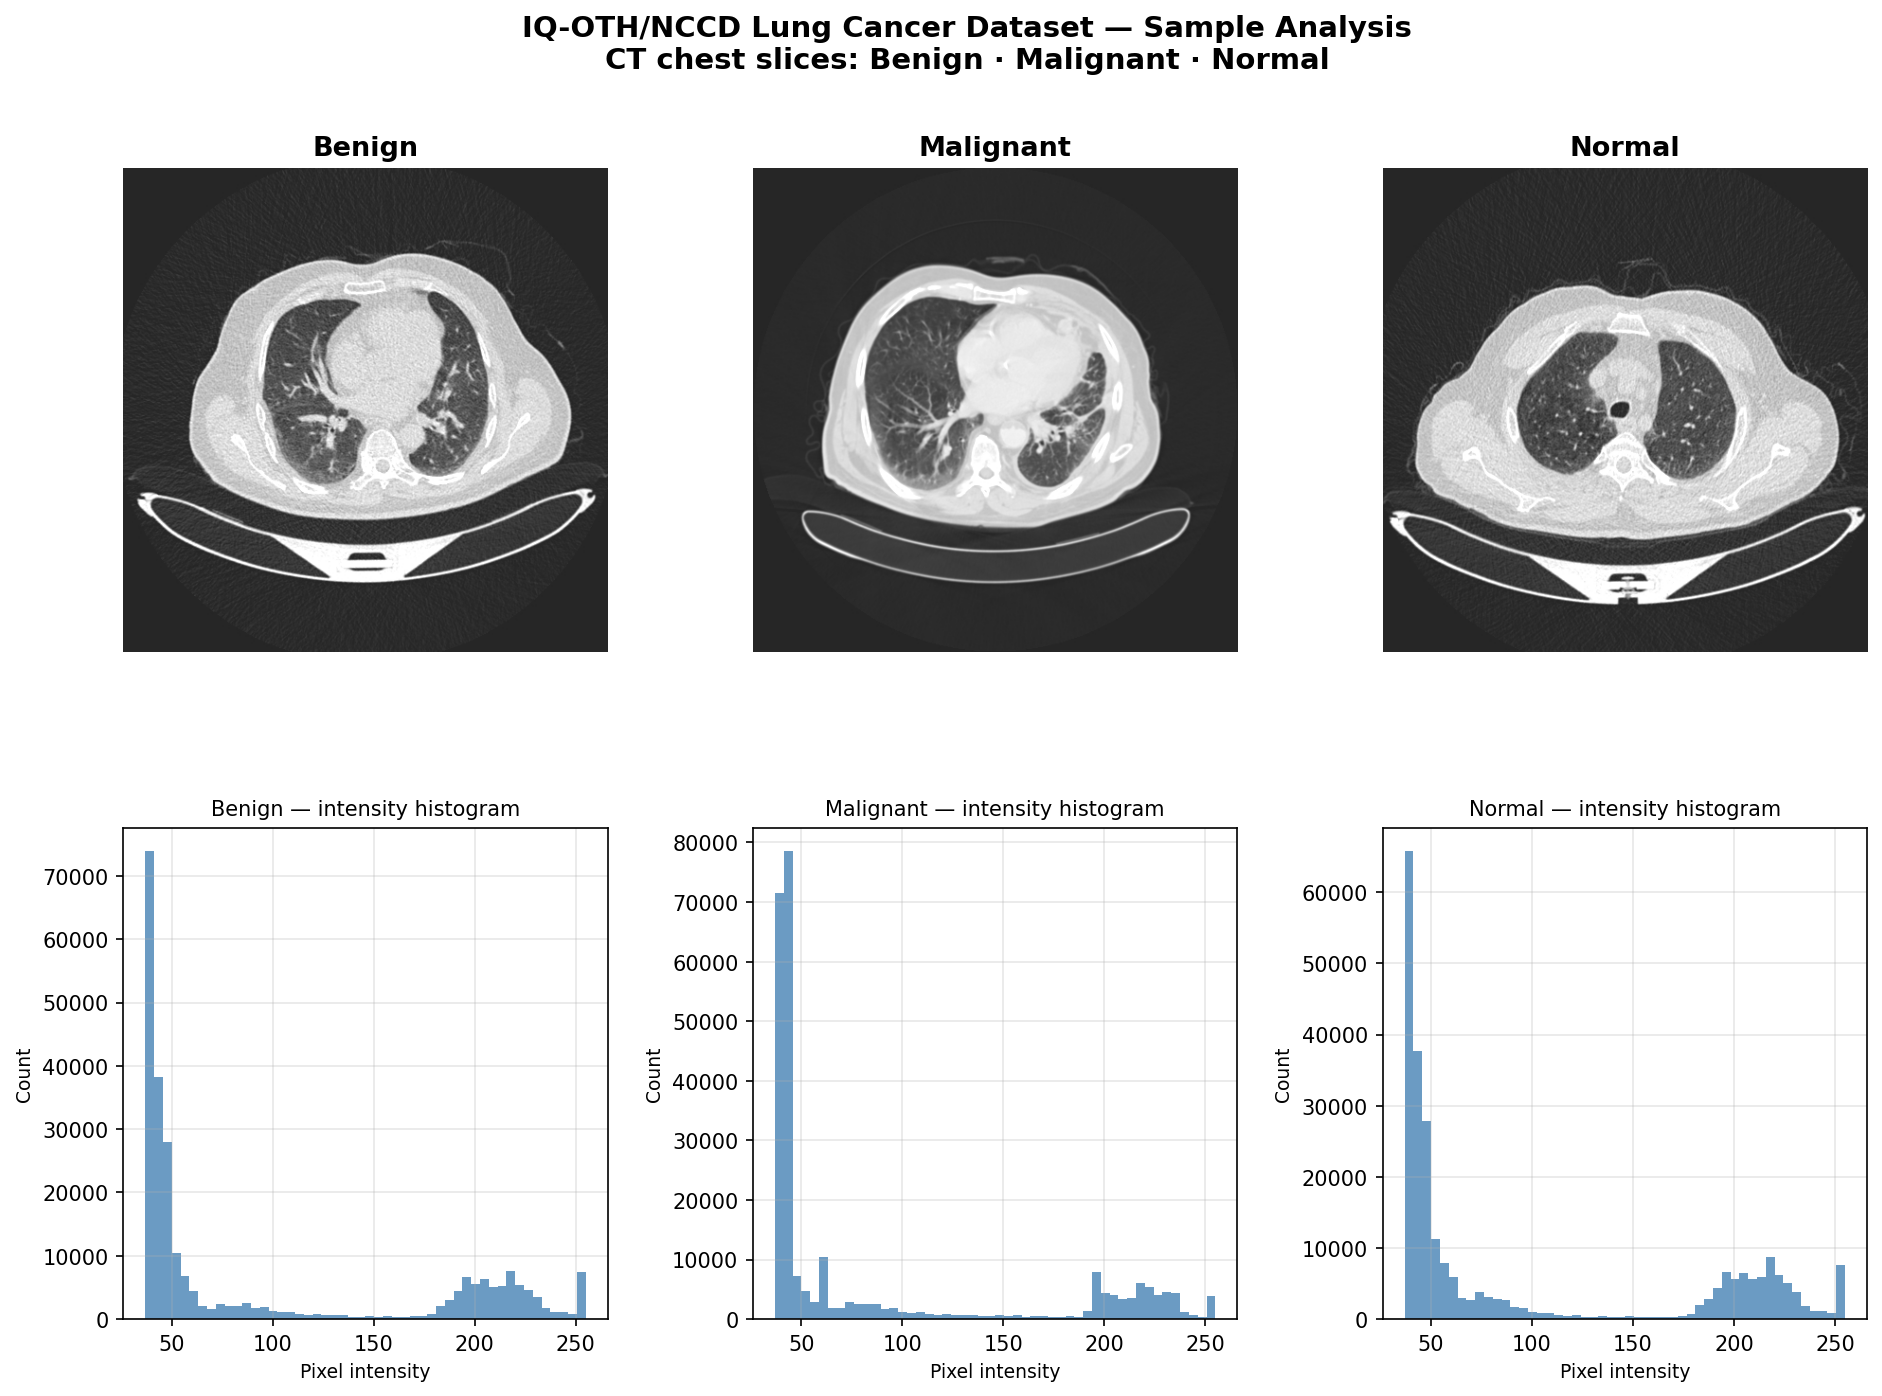

In [3]:
# Display the saved visualization inline
from IPython.display import Image as IPyImage
IPyImage(str(test_iq_oth.OUTPUT_DIR / "IQ-OTH_NCCD_sample_analysis.png"), width=900)

---

## 2. OASIS-1 — Cross-Sectional Brain MRI

### Background
Open Access Series of Imaging Studies (Washington University). **436 subjects** aged 18–96,
including 100 subjects over 60 with clinically diagnosed Alzheimer's disease (CDR 0.5–2).

### Imaging Modality
**T1-weighted MPRAGE 3D structural brain MRI** (1 mm³ voxels, sagittal orientation).
Format: **Analyze 7.5** (`.hdr` + `.img` pair) — the precursor to NIfTI.

### Per-Subject Data
- `RAW/` — 4 raw MPRAGE acquisitions (motion-averaged at processing)
- `PROCESSED/MPRAGE/T88_111/` — atlas-registered brain (Talairach T88 space), skull-stripped
- `FSL_SEG/` — FSL tissue segmentation: **Gray Matter / White Matter / CSF**
- `.txt` metadata — CDR, MMSE, age, sex, handedness, education, SES, brain volumes (eTIV, nWBV, ASF)

### Tools Used
| Tool | Role |
|------|------|
| `nibabel.load()` | Directly loads Analyze 7.5 `.hdr/.img` volumes (full 3D array + header) |
| `NiftiImageWrapper` (SDK) | Wraps nibabel; provides pyramid-level region reads on the processed volume |
| `numpy` | Volume statistics: voxel counts, intensity range, brain-only (non-zero) stats |
| `matplotlib` | 6-panel visualization: sagittal/coronal/axial for MRI + FSL segmentation |

### Sample
Subject **OAS1_0001_MR1** — Female, 74 years, CDR=0 (cognitively normal), MMSE=29.

### Clinical Relevance
Brain volume metrics (nWBV, gray matter fraction) derived from these MRI scans are key
biomarkers for Alzheimer's disease progression — directly usable for dementia classification models.

In [4]:
import importlib, test_oasis1
importlib.reload(test_oasis1)
test_oasis1.main()


  OASIS-1 Brain MRI Dataset — Sample Probe
  Subject  : OAS1_0001_MR1
  Modality : T1-weighted MPRAGE (3D structural brain MRI)
  Format   : Analyze 7.5 (.hdr/.img)
  Domain   : Radiology / Neuroscience

--- Subject Metadata ---
  SESSION ID  : OAS1_0001_MR1
  AGE         : 74
  M/F         : Female
  HAND        : Right
  EDUC        : 2
  SES         : 3
  CDR         : 0
  MMSE        : 29
  eTIV        : 1344.00
  ASF         : 1.31
  nWBV        : 0.743

--- RAW Acquire Volume (mpr-1) ---

  [RAW mpr-1]
    Shape        : (256, 256, 128, 1)
    Voxel count  : 8,388,608
    Non-zero     : 3,175,651  (37.9%)
    Intensity    : min=0.0  max=4095.0  mean=305.59  std=570.66
    Brain only   : mean=807.23  std=674.75

--- Processed T88 Atlas Volume ---

  [T88 Masked GFC]
    Shape        : (176, 208, 176, 1)
    Voxel count  : 6,443,008
    Non-zero     : 1,667,264  (25.9%)
    Intensity    : min=0.0  max=3126.0  mean=229.68  std=429.57
    Brain only   : mean=887.59  std=359.36

  [S

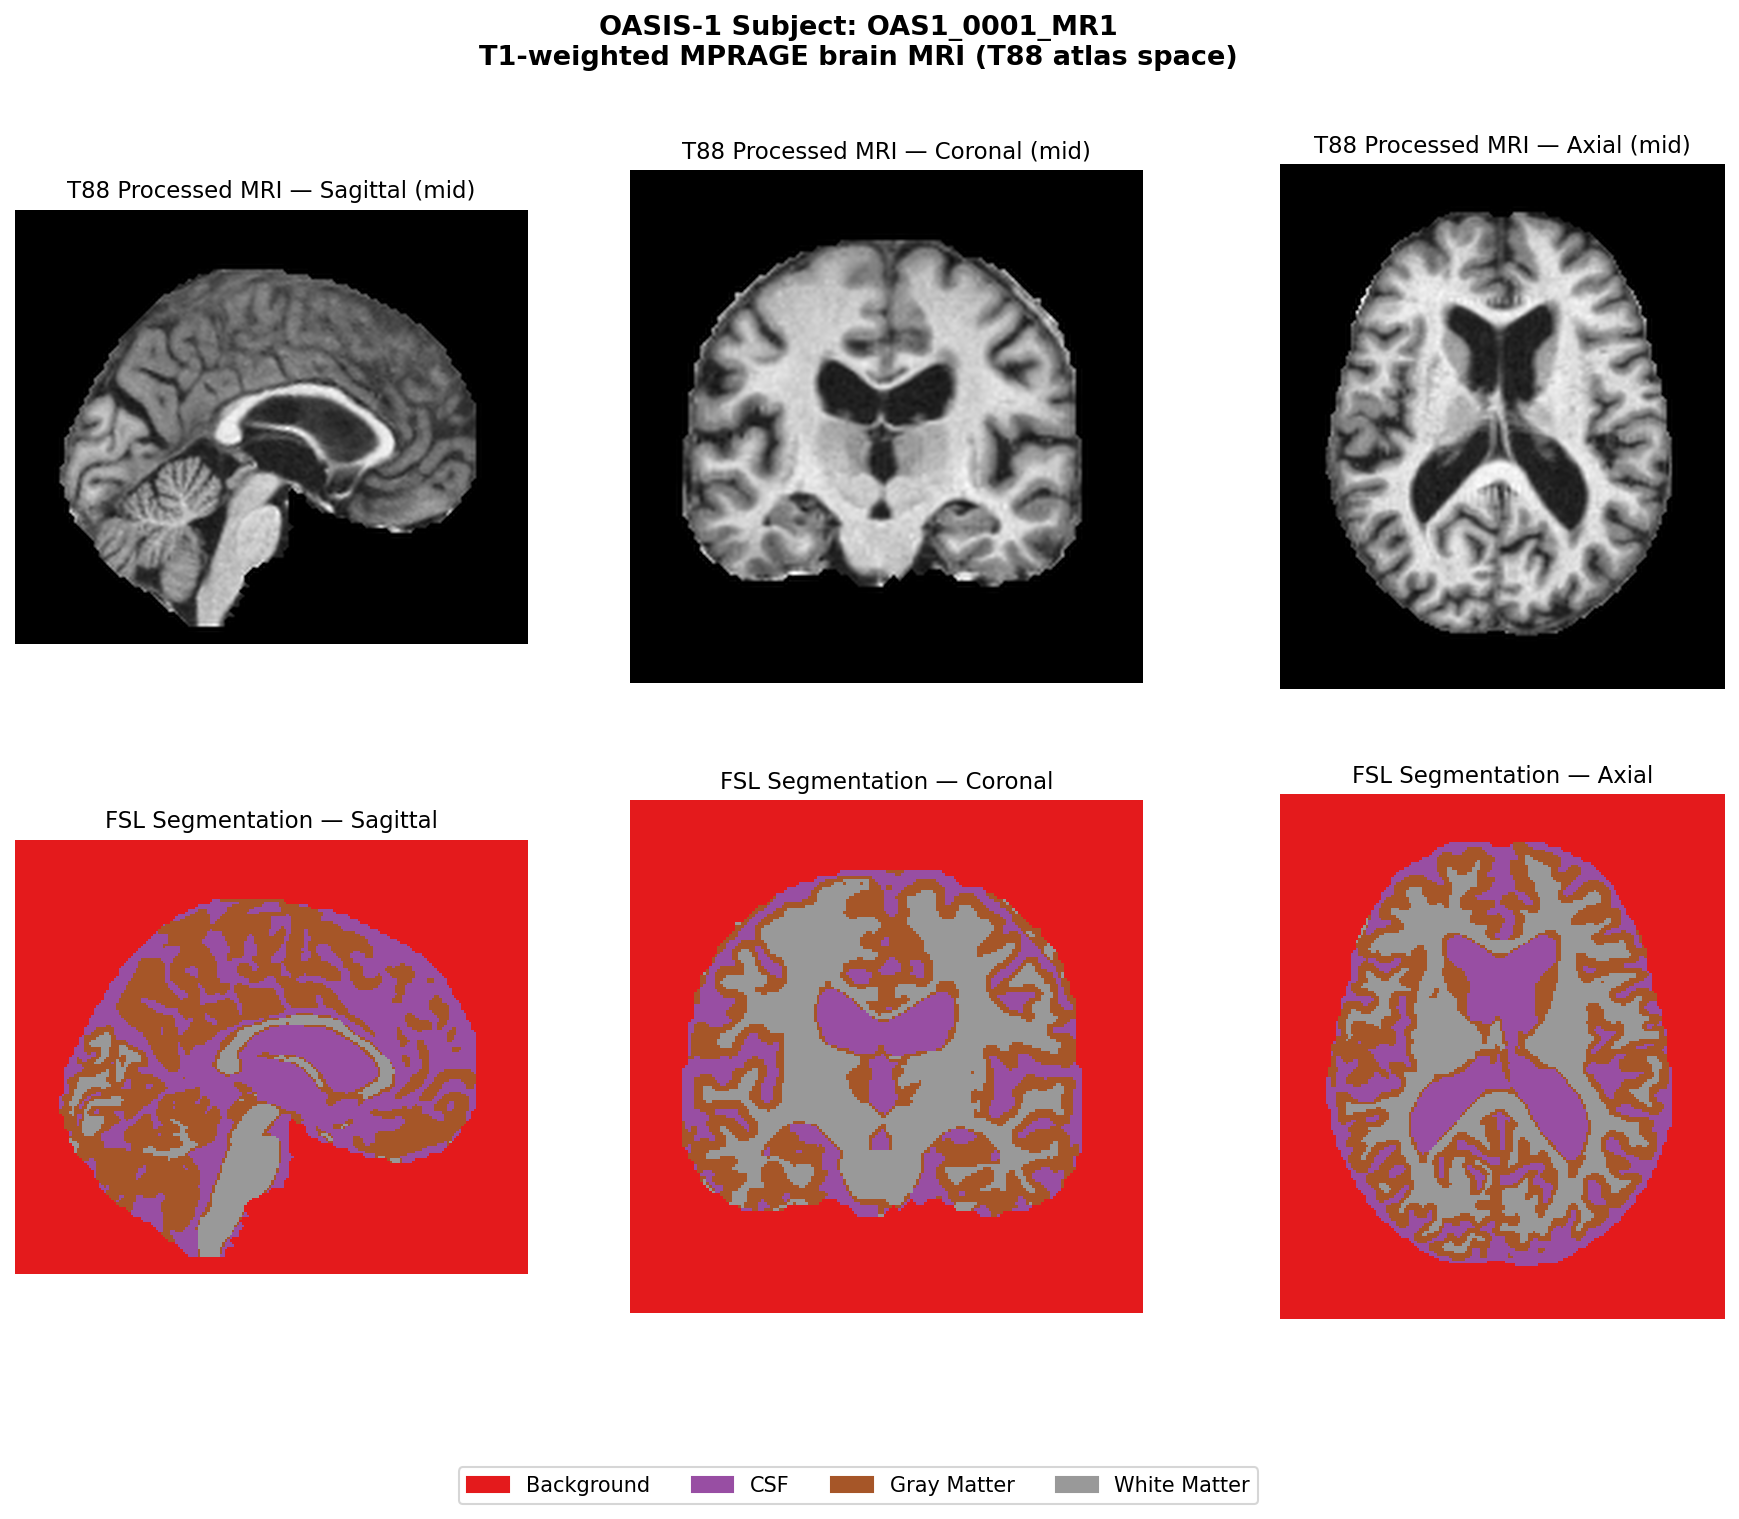

In [5]:
from IPython.display import Image as IPyImage
IPyImage(str(test_oasis1.OUTPUT_DIR / f"{test_oasis1.SUBJECT_ID}_visualization.png"), width=900)

---

## 3. PKG HistologyHSI-GB — Hyperspectral Glioblastoma Histology

### Background
13-patient dataset of H&E-stained glioblastoma (GBM) tissue slides captured with a
**hyperspectral push-broom camera** (HEADWALL Hyperspec III) on an Olympus BX-53 microscope
at 20× magnification. 469 annotated ROIs: **Tumor (_T)** vs **Non-Tumor (_NT)**.

### Imaging Modality
**Hyperspectral Imaging (HSI)** — captures **826 contiguous spectral bands** from 400 to 1000 nm
(visible + near-infrared) at each pixel. A standard RGB camera captures only 3 channels;
HSI captures the full spectral signature, enabling detection of biochemical tissue differences
invisible to the human eye.

### Format: ENVI BIL
- `raw.hdr` — ASCII header describing the cube geometry (lines, samples, bands, wavelengths)
- `raw` — flat binary raster file (800 × 1004 × 826 = ~1.2 GB per ROI)
- `whiteReference`, `darkReference` — calibration frames for reflectance normalisation
- `rgb.png` — 3-band RGB preview rendering

### Tools Used
| Tool | Role |
|------|------|
| `spectral.io.envi.open()` | Load ENVI BIL header + binary cube with full wavelength metadata |
| `numpy` | Calibration (reflectance = (raw − dark) / (white − dark)), per-band stats, spectral signatures |
| `SimpleImageWrapper` (SDK) | Load `rgb.png` preview via unified interface |
| `matplotlib` | 6-panel visualization: RGB preview, pseudo-RGB, NIR band, spectral mean ± std, pixel signatures, band variance |

### Sample
Patient **P1**, ROI **ROI_01_C01_T** — a **Tumor** region.

### Clinical Relevance
HSI can discriminate GBM tumor tissue from necrosis and healthy brain based on spectral
signatures — a key capability for intraoperative margin detection during brain tumor surgery.

> ⚠️ Loading the 1.2 GB raw cube takes ~30–60 seconds. This is expected.

In [6]:
import importlib, test_pkg_hsi
importlib.reload(test_pkg_hsi)
test_pkg_hsi.main()


  PKG HistologyHSI-GB — Hyperspectral Histology Probe
  Sample   : P1/ROI_01_C01_T  [Tumor]
  Modality : Hyperspectral Imaging (HSI)
  Format   : ENVI BIL  (raw + raw.hdr)
  Domain   : Pathology (Glioblastoma)

--- ENVI Header (raw cube) ---
  Lines × Samples × Bands : 800 × 1004 × 826
  Interleave              : bil
  Wavelength range        : 400.48 – 1000.73 nm
  Sensor                  : Unknown
  White ref shape         : 1 × 1004 × 826

--- Loading Hyperspectral Cubes ---
  Loading raw cube ... (this may take a moment for a 1.2 GB file)
  Raw cube loaded  : shape=(800, 1004, 826)  dtype=float32
  Applying white/dark calibration ...
  Calibrated cube  : min=0.0219  max=1.0000

--- Pixel Statistics ---
  Full cube stats  : mean=0.8215  std=0.2183  min=0.0219  max=1.0000

--- Per-Band Statistics (20 sampled bands) ---
   Band    WL(nm)      Mean       Std
      0     400.5   0.77666   0.09586
     43     431.8   0.76931   0.10587
     86     463.1   0.72884   0.12377
    130     49

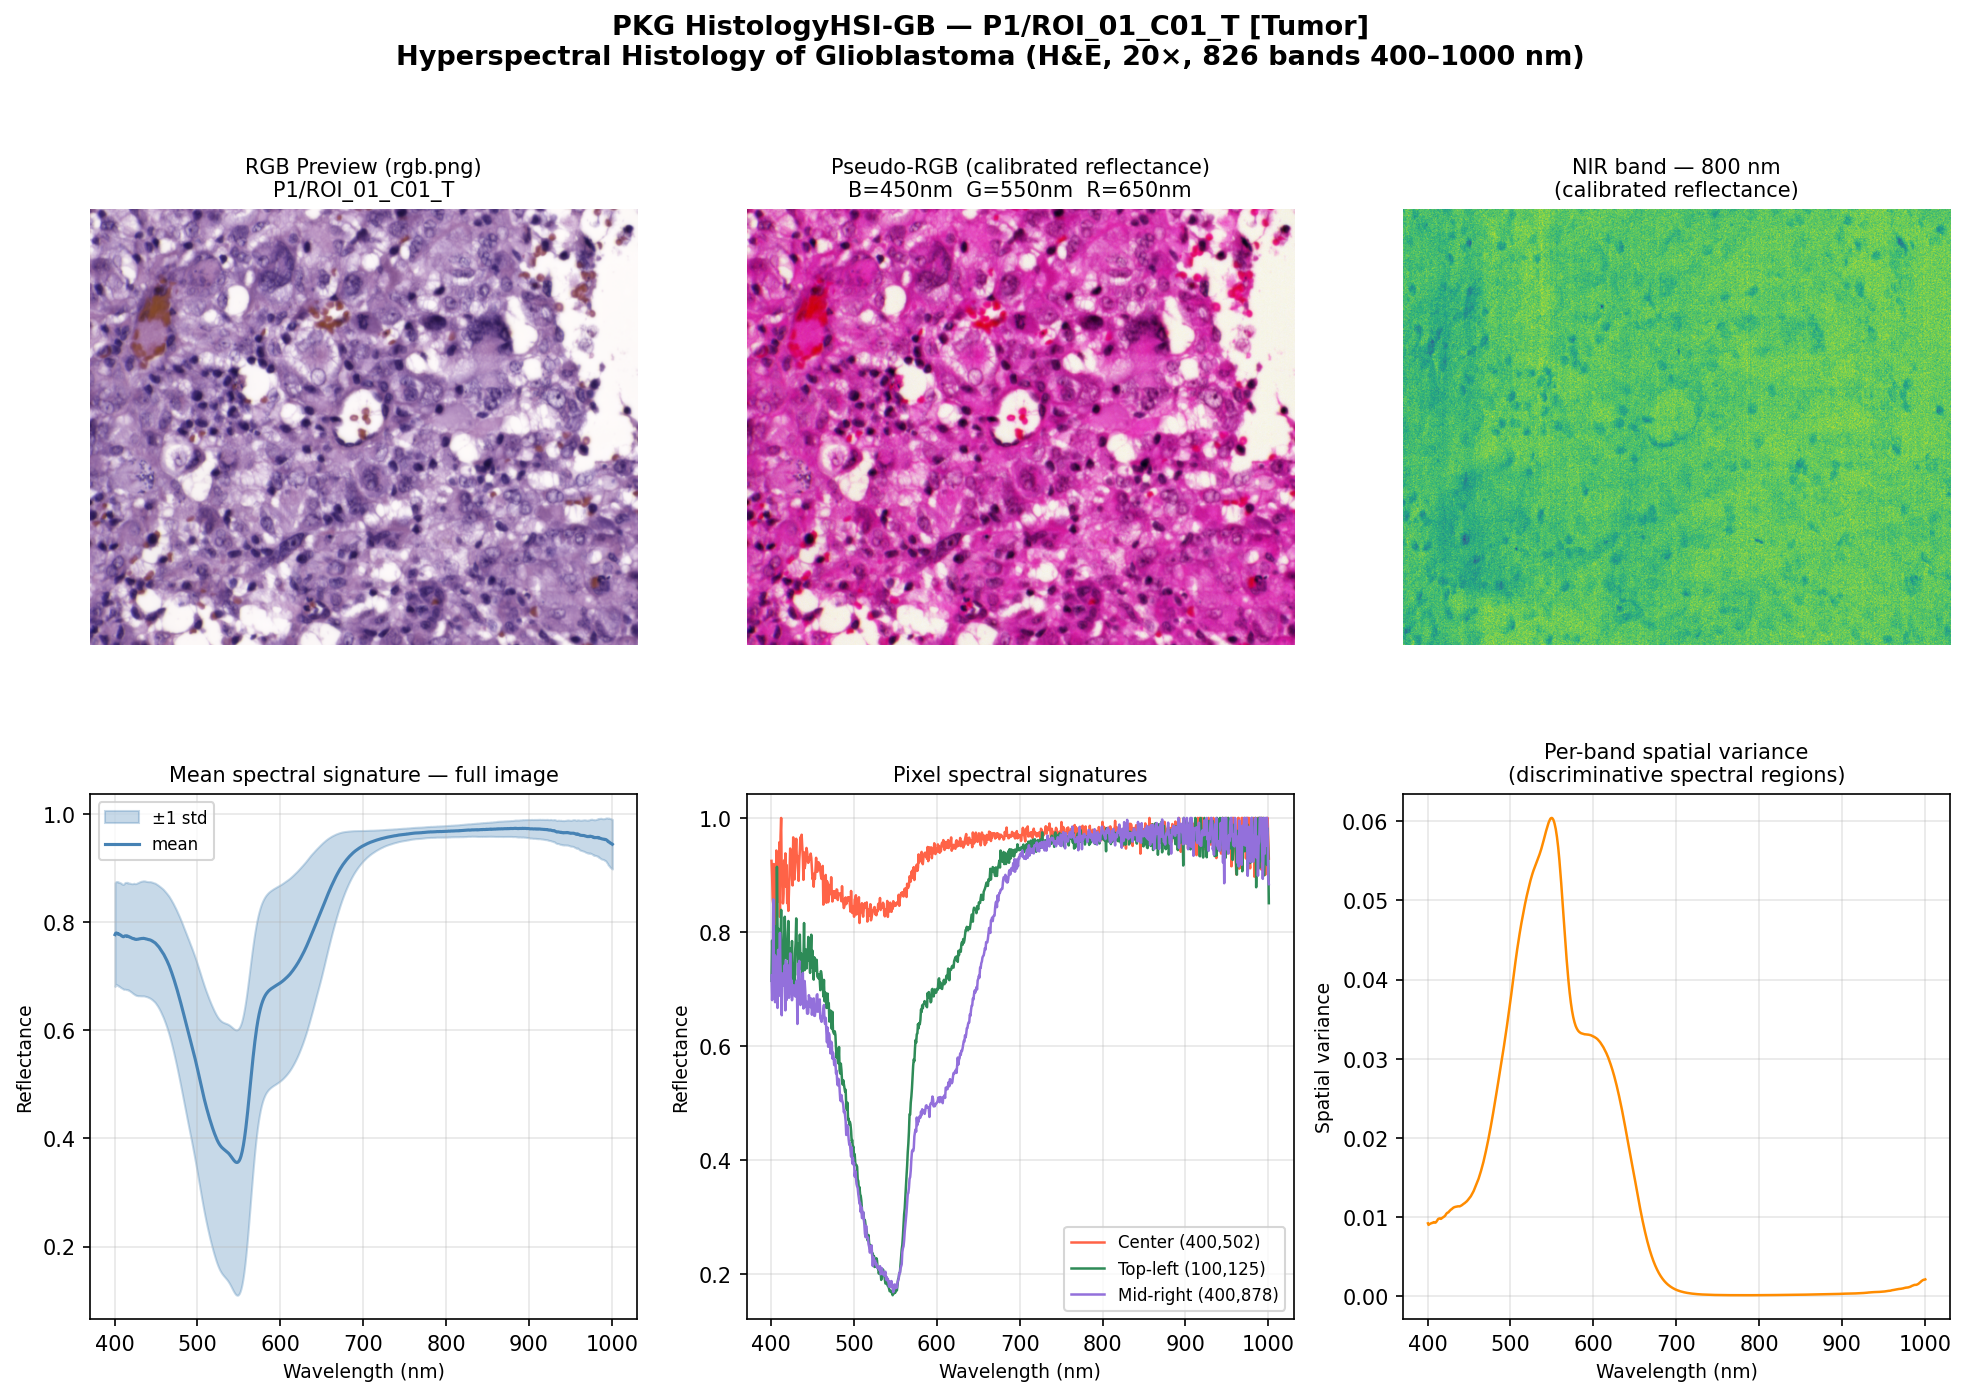

In [7]:
from IPython.display import Image as IPyImage
IPyImage(str(test_pkg_hsi.OUTPUT_DIR / f"{test_pkg_hsi.PATIENT_ID}_{test_pkg_hsi.ROI_ID}_analysis.png"), width=950)

---

## 4. Quilt1M — 1M Image-Text Pairs for Histopathology

### Background
The largest open-source vision-language histopathology dataset: **~1 million** image-text pairs
spanning **18 pathology sub-specialties** at various magnifications (10×, 20×, 40×).
Assembled from 4 distinct sources with very different caption quality profiles.

### Source Subsets
| Subset | Count | Origin | Caption Quality |
|--------|-------|--------|-----------------|
| `quilt` | 802K | YouTube pathology videos (frame extractions + auto-transcription) | High — educational narration |
| `openpath` | 133K | Twitter/social media (pathology community) | Medium — informal clinical descriptions |
| `pubmed` | 59K | PubMed open-access figure captions | High — peer-reviewed academic text |
| `laion` | 22K | LAION web-scraped | Low — web alt-text, noisy |

### Metadata per Image (`quilt_1M_lookup.csv`)
- `caption`, `corrected_text`, `noisy_text`, `roi_text`
- `pathology` — list of sub-specialties (e.g. `['Dermatopathology', 'Breast']`)
- `med_umls_ids` — UMLS structured medical entity extraction
- `magnification`, `height`, `width`
- `not_histology` flag, `single_wsi` flag

### Tools Used
| Tool | Role |
|------|------|
| `SimpleImageWrapper` (SDK) | Load JPEG/PNG via unified interface |
| `PIL.Image` | Format, mode, size, EXIF |
| `pandas` | Lookup CSV row by `image_path`, extract full metadata |
| `numpy` | Pixel stats, per-channel RGB analysis |
| `matplotlib` | Image display + intensity histogram with metadata annotation |

### Samples (one per source subset)
The 4 sub-tests below each probe a different source to highlight caption quality variation.

### 4a. Quilt1M — PubMed Subset
**Image:** `c901a42b-0ab9-45d9-809d-dd646effcf9c_1.jpg`  
**Caption:** IDH1 immunocytochemistry in MG63 and U2OS osteosarcoma cell lines  
**Source:** PubMed open-access figure from a peer-reviewed article

In [8]:
import importlib, test_quilt1m_pubmed
importlib.reload(test_quilt1m_pubmed)
# test_quilt1m_pubmed just calls run_test() at __main__; we call it directly here
from _quilt1m_common import run_test
from pathlib import Path
run_test(
    "pubmed",
    "c901a42b-0ab9-45d9-809d-dd646effcf9c_1.jpg",
    Path("data/Quilt1M_pubmed"),
    Path("output/Quilt1M_pubmed"),
)


  Quilt1M Dataset — PUBMED subset
  Sample : c901a42b-0ab9-45d9-809d-dd646effcf9c_1.jpg
  Modality : Optical microscopy (H&E histopathology)
  Domain   : Pathology
  Format     : JPEG
  Mode       : RGB
  Size       : 281W × 222H px
  SDK wrapper: SimpleImageWrapper  dims=[281, 222]
  Intensity  : min=0.0  max=255.0  mean=247.4  std=23.1
  Channels   : R=248.1  G=246.2  B=247.9

--- CSV Metadata ---
  Unnamed: 0          : 33
  caption             : The immunocytochemistry of IDH1 in MG63 and U2OS. IDH1 is specifically detected in the cytoplasm of 
  subset              : pubmed
  split               : train
  not_histology       : 0
  single_wsi          : 1

  [VIZ] Saved → output/Quilt1M_pubmed/Quilt1M_pubmed_c901a42b-0ab9-45d9-809d-dd646effcf9c_1_analysis.png

[REPORT] Saved → output/Quilt1M_pubmed/Quilt1M_pubmed_c901a42b-0ab9-45d9-809d-dd646effcf9c_1_report.json

[DONE]


In [9]:
from IPython.display import Image as IPyImage
from pathlib import Path
out = sorted(Path("output/Quilt1M_pubmed").glob("*.png"))
if out: IPyImage(str(out[-1]), width=800)

### 4b. Quilt1M — YouTube (Quilt) Subset
**Image:** `dTr3MNl1FxE_image_c54e9a8d-...jpg`  
**Caption:** Nephrogenic systemic fibrosis — dermatopathology / soft tissue / breast  
**Source:** Frame extracted from a YouTube pathology educational video

In [10]:
run_test(
    "quilt",
    "dTr3MNl1FxE_image_c54e9a8d-9348-456a-9645-3b8921eb0b79.jpg",
    Path("data/Quilt1M_quilt"),
    Path("output/Quilt1M_quilt"),
)


  Quilt1M Dataset — QUILT subset
  Sample : dTr3MNl1FxE_image_c54e9a8d-9348-456a-9645-3b8921eb0b79.jpg
  Modality : Optical microscopy (H&E histopathology)
  Domain   : Pathology
  Format     : JPEG
  Mode       : RGB
  Size       : 1920W × 1040H px
  SDK wrapper: SimpleImageWrapper  dims=[1920, 1040]
  Intensity  : min=0.0  max=255.0  mean=225.2  std=41.4
  Channels   : R=225.7  G=220.6  B=229.2

--- CSV Metadata ---
  Unnamed: 0          : 2
  caption             : Nephrogenic systemic fibrosis is a fibrotic disorder with deep involvement that goes down to the fas
  subset              : quilt
  split               : train
  pathology           : ['Dermatopathology', 'Soft tissue', 'Breast']
  roi_text            : []
  noisy_text          :  some eosinophils in there as well. So just remember that. And again, maybe at some point in the fut
  corrected_text      :  some eosinophils in there as well. So just remember that. And again, maybe at some point in the fut
  med_umls_ids     

In [11]:
out = sorted(Path("output/Quilt1M_quilt").glob("*.png"))
if out: IPyImage(str(out[-1]), width=800)

### 4c. Quilt1M — OpenPath (Twitter/Social Media) Subset
**Image:** `994701482116173824_0.jpg`  
**Caption:** Peritoneal biopsy — DailyDx challenge (UMichPath / SurgPath community)  
**Source:** Twitter/social media pathology post

In [12]:
run_test(
    "openpath",
    "994701482116173824_0.jpg",
    Path("data/Quilt1M_openpath"),
    Path("output/Quilt1M_openpath"),
)


  Quilt1M Dataset — OPENPATH subset
  Sample : 994701482116173824_0.jpg
  Modality : Optical microscopy (H&E histopathology)
  Domain   : Pathology
  Format     : JPEG
  Mode       : RGB
  Size       : 360W × 225H px
  SDK wrapper: SimpleImageWrapper  dims=[360, 225]
  Intensity  : min=0.0  max=255.0  mean=190.8  std=38.6
  Channels   : R=199.2  G=170.9  B=202.4

--- CSV Metadata ---
  Unnamed: 0          : 0
  caption             : Peritoneum, Day 4 These two biopsies (1 & 2) were taken from the same patient. What is your DailyDx 
  subset              : openpath
  split               : train
  not_histology       : 0
  single_wsi          : 1

  [VIZ] Saved → output/Quilt1M_openpath/Quilt1M_openpath_994701482116173824_0_analysis.png

[REPORT] Saved → output/Quilt1M_openpath/Quilt1M_openpath_994701482116173824_0_report.json

[DONE]


In [13]:
out = sorted(Path("output/Quilt1M_openpath").glob("*.png"))
if out: IPyImage(str(out[-1]), width=800)

### 4d. Quilt1M — LAION (Web-Scraped) Subset
**Image:** `00004000040081.jpg`  
**Caption:** Cytosolic Sulfotransferase 1A1 / SULT1A1 antibody  
**Source:** LAION large-scale web-scraped image-text pairs

> Note: LAION captions are typically lower quality (alt-text / product descriptions).  
> Observe how metadata fields like `pathology`, `magnification`, and UMLS IDs are often absent.

In [14]:
run_test(
    "laion",
    "00004000040081.jpg",
    Path("data/Quilt1M_laion"),
    Path("output/Quilt1M_laion"),
)


  Quilt1M Dataset — LAION subset
  Sample : 00004000040081.jpg
  Modality : Optical microscopy (H&E histopathology)
  Domain   : Pathology
  Format     : JPEG
  Mode       : RGB
  Size       : 400W × 300H px
  SDK wrapper: SimpleImageWrapper  dims=[400, 300]
  Intensity  : min=0.0  max=255.0  mean=209.9  std=53.4
  Channels   : R=196.4  G=204.7  B=228.7

--- CSV Metadata ---
  Unnamed: 0          : 17
  caption             : Cytosolic Sulfotransferase 1A1 /SULT1A1 Antibody
  subset              : laion
  split               : train
  not_histology       : 0
  single_wsi          : 1

  [VIZ] Saved → output/Quilt1M_laion/Quilt1M_laion_00004000040081_analysis.png

[REPORT] Saved → output/Quilt1M_laion/Quilt1M_laion_00004000040081_report.json

[DONE]


In [15]:
out = sorted(Path("output/Quilt1M_laion").glob("*.png"))
if out: IPyImage(str(out[-1]), width=800)

---

## 5a. Spinal Multiple Myeloma — DICOM (Spectral CT)

### Background
67-patient dataset from the Cancer Imaging Archive (TCIA). CT acquired with a
**Philips IQon Spectral CT** (dual-layer dual-energy) at 564,464 axial DICOM slices total.
Multiple Myeloma (MM) is a plasma cell malignancy that primarily invades the spine.

### Imaging Modality
**Spectral (Dual-Energy) CT** — a single acquisition produces multiple reconstructions:
- `MonoE 40/80/120 keVHU` — virtual mono-energetic images at different keV levels
- `Calcium Suppression 25/50/75/100` — calcium-suppressed parametric maps
- `MyelXXXkonv` — conventional CT reconstruction
- `Segmentation` — DICOM SEG objects (lesion + spine masks)

### Tools Used
| Tool | Role |
|------|------|
| `pydicom.dcmread()` | Full DICOM tag dump; pixel array extraction; HU conversion (slope + intercept) |
| `DicomImageWrapper` (SDK) | Single-slice load via unified region-read interface |
| `SimpleITK.ImageSeriesReader` | Reconstruct the full 3D volume from the DICOM series directory |
| `pandas` | Parse `metadata.csv` — series manifest with UIDs, modalities, file counts |
| `matplotlib` | Slice + 3D orthogonal views + HU histogram |

### Sample
Patient **Myel_001** — series **MonoE 80 keV** (1095 slices, ~standard soft-tissue equivalent).

> **Local copy:** Only the first 20 slices are stored in `data/Spinal_DICOM/` for portability.  
> `SimpleITK` will attempt to read the full series from the original dataset path if available.

In [16]:
import importlib, test_spinal_dicom
importlib.reload(test_spinal_dicom)
test_spinal_dicom.main()


  Spinal Multiple Myeloma — DICOM Probe
  Patient  : Myel_001
  Series   : MonoE_80keVHU
  Modality : Spectral CT (Dual-Energy) — Spine
  Domain   : Radiology / Oncology

  Found 20 DICOM slice(s) in local copy (MonoE_80keVHU)

--- pydicom: First Slice (1-0001.dcm) ---

  Key Clinical DICOM Tags:
    PatientID                     : Myel_001
    StudyDate                     : 20150106
    Modality                      : CT
    SeriesDescription             : MonoE 80keV[HU]
    Manufacturer                  : Philips
    ManufacturerModelName         : IQon - Spectral CT
    KVP                           : 120
    SliceThickness                : 0.9
    PixelSpacing                  : ['0.9765625', '0.9765625']
    Rows                          : 512
    Columns                       : 512
    BitsAllocated                 : 16
    RescaleIntercept              : -1024.0
    RescaleSlope                  : 1.0
    ImagePositionPatient          : ['-253.44543695', '-104.14535547', '-55

TypeError: Object of type ndarray is not JSON serializable

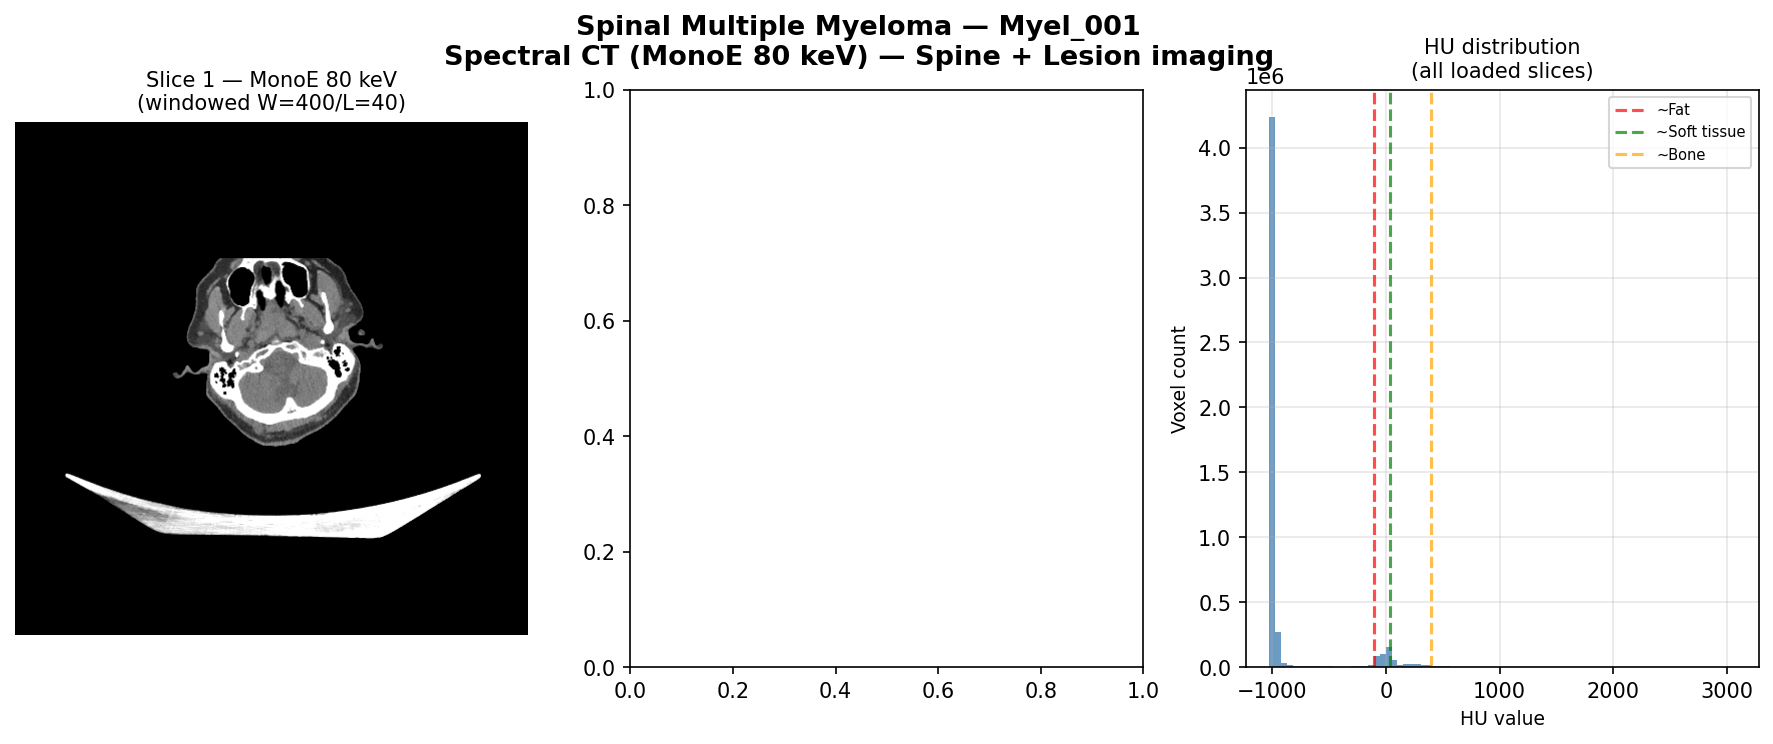

In [ ]:
from IPython.display import Image as IPyImage
IPyImage(str(test_spinal_dicom.OUTPUT_DIR / f"{test_spinal_dicom.PATIENT_ID}_DICOM_analysis.png"), width=950)

---

## 5b. Spinal Multiple Myeloma — NIfTI Segmentation Masks

### Background
The same 67 patients have expert-refined segmentation masks generated by nnU-Net v2
and manually corrected by radiologists. Two masks per patient:
- **Spine segmentation** — vertebra-level anatomy labels (C1–L5 + sacrum), one label per vertebral body
- **Lesion segmentation** — Multiple Myeloma lesion foci (distinct label per lesion cluster)

### Format
**NIfTI (.nii)** — standard neuroimaging format supported natively by nibabel and the SDK.
Stored in `MM_NIfTI_Segmentation/Myel_XXX/` alongside the DICOM series.

### Tools Used
| Tool | Role |
|------|------|
| `nibabel.load()` | Load NIfTI volume + header (voxel dims, affine, data type) |
| `NiftiImageWrapper` (SDK) | Pyramid-level region read of mid-slice |
| `numpy` | Per-label voxel counts, volume (mm³ and cm³), co-registration check |
| `matplotlib` | 6-panel: sagittal/coronal/axial for spine mask + lesion overlay |
| `pandas` | `metadata.csv` series lookup |

### Sample
Patient **Myel_001** — spine segmentation + lesion segmentation masks.

### Clinical Relevance
The combination of spine anatomy mask + lesion mask enables:
- **Lesion localisation** — which vertebra is affected
- **Tumor burden quantification** — total lesion volume in cm³
- **Treatment response tracking** — lesion volume change over follow-up scans

In [ ]:
import importlib, test_spinal_nifti
importlib.reload(test_spinal_nifti)
test_spinal_nifti.main()


  Spinal Multiple Myeloma — NIfTI Segmentation Probe
  Patient  : Myel_001
  Masks    : spine_segmentation + lesions_segmentation
  Modality : Spectral CT derived masks (NIfTI)
  Domain   : Radiology / Oncology

--- Spine Segmentation Mask ---

  [Spine mask]
    Shape          : [512, 512, 1095]
    Voxel size     : [0.9766, 0.9766, 0.6005] mm
    Voxel volume   : 0.5727 mm³
    Data dtype     : uint16

  [Spine] — unique labels: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24]
    Label   1 (Vertebra 1      ):   31,722 voxels  (   18167.2 mm³ / 18.1672 cm³)
    Label   2 (Vertebra 2      ):   41,466 voxels  (   23747.6 mm³ / 23.7476 cm³)
    Label   3 (Vertebra 3      ):   26,723 voxels  (   15304.3 mm³ / 15.3043 cm³)
    Label   4 (Vertebra 4      ):   25,302 voxels  (   14490.5 mm³ / 14.4905 cm³)
    Label   5 (Vertebra 5      ):   26,563 voxels  (   15212.6 mm³ / 15.2126 cm³)
    Label   6 (Vertebra 6      ):   33,262 voxels  (   19049.2 

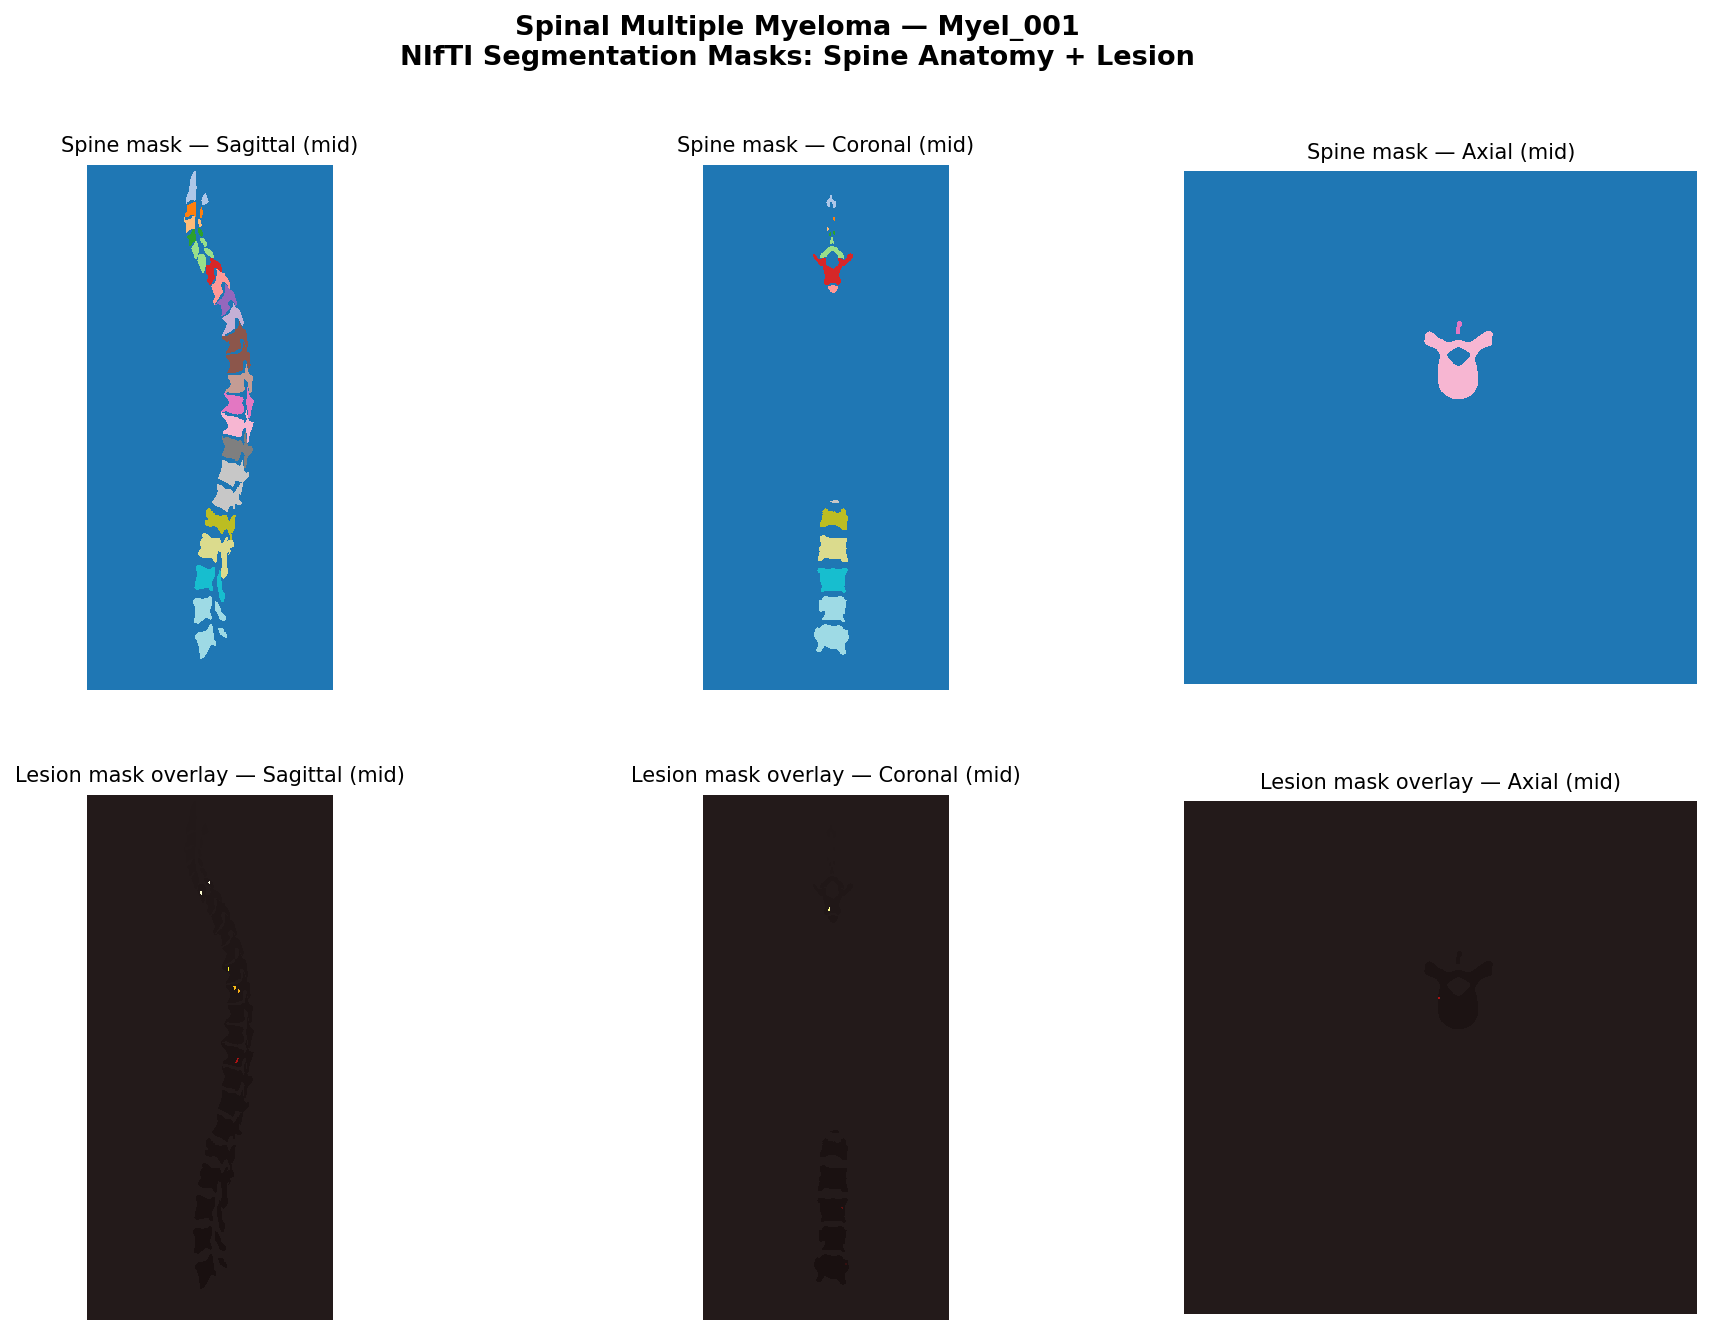

In [ ]:
from IPython.display import Image as IPyImage
IPyImage(str(test_spinal_nifti.OUTPUT_DIR / f"{test_spinal_nifti.PATIENT_ID}_NIfTI_segmentation.png"), width=950)

---

## Summary — All 10 Tests

The cell below collects output report paths and prints a final summary.

In [ ]:
from pathlib import Path
import json

output_root = Path("output")
reports = sorted(output_root.rglob("*.json"))

print(f"{'Report':<60} {'Size':>8}")
print("-" * 70)
for r in reports:
    try:
        data = json.loads(r.read_text())
        label = f"{data.get('dataset','?')} / {data.get('patient', data.get('subject', data.get('roi', data.get('subset', ''))))}"
    except Exception:
        label = "(parse error)"
    size_kb = r.stat().st_size // 1024
    print(f"  {str(r.relative_to(output_root)):<58} {size_kb:>6} KB")

pngs = sorted(output_root.rglob("*.png"))
print(f"\n{len(pngs)} visualization PNG(s) generated.")
for p in pngs:
    print(f"  {p}")

Report                                                           Size
----------------------------------------------------------------------
  IQ-OTH_NCCD/IQ-OTH_NCCD_report.json                             6 KB
  Oasis1/OAS1_0001_MR1_report.json                                7 KB
  PKG_HistologyHSI_GB/P1_ROI_01_C01_T_report.json                51 KB
  Quilt1M_laion/Quilt1M_laion_00004000040081_report.json          1 KB
  Quilt1M_openpath/Quilt1M_openpath_994701482116173824_0_report.json      1 KB
  Quilt1M_pubmed/Quilt1M_pubmed_c901a42b-0ab9-45d9-809d-dd646effcf9c_1_report.json      1 KB
  Quilt1M_quilt/Quilt1M_quilt_dTr3MNl1FxE_image_c54e9a8d-9348-456a-9645-3b8921eb0b79_report.json      1 KB
  Spinal_DICOM/Myel_001_DICOM_report.json                         6 KB
  Spinal_NIfTI/Myel_001_NIfTI_report.json                        14 KB

9 visualization PNG(s) generated.
  output/IQ-OTH_NCCD/IQ-OTH_NCCD_sample_analysis.png
  output/Oasis1/OAS1_0001_MR1_visualization.png
  output/PKG_Histo